<a href="https://colab.research.google.com/github/salonii-byte/tb-igra-longitudinal-analysis/blob/main/tb_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

df = pd.read_csv('case_study.csv')
df.head()


,Baseline,AGE,GENDER,HT,WT,BMI,Baseline IGRA,Month-6,Month-6 IGRA,Month-12,...,Month-24,Month24 IGRA,BCG VACCINATION,OUTCOME,IFN-GAMMA-UNS,IFN-GAMMA-C+E,SMOKING,TB STATUS,DIABETES STATUS,REGION
0,TB-01,44,MALE,175,84.0,27.43,POSITIVE,TB-150,INDETERMINATE,TB-299,...,TB-597,POSITIVE,Yes,NON-PROGRESSOR,960.890,1001.162,Yes,Latent,Yes,Rural
1,TB-02,36,Female,165,60.0,22.04,NEGATIVE,TB-151,NEGATIVE,TB-300,...,TB-598,NEGATIVE,Yes,NON-CONVERTER,1007.180,1025.208,No,Latent,Yes,Rural
2,TB-03,14,MALE,137,58.0,30.90,POSITIVE,TB-152,POSITIVE,TB-301,...,TB-599,POSITIVE,Yes,NON-PROGRESSOR,999.154,1021.206,Yes,Latent,Yes,Rural
3,TB-04,12,MALE,132,55.0,31.57,NEGATIVE,TB-153,POSITIVE,TB-302,...,TB-600,POSITIVE,Yes,PROGRESSOR,902.044,1315.564,Yes,Active,Yes,Rural
4,TB-05,50,Female,161,55.0,21.22,POSITIVE,TB-154,POSITIVE,TB-303,...,TB-601,NEGATIVE,No,REVERTER,997.144,1009.186,No,Latent,Yes,Rural


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('case_study.csv')
df.columns = df.columns.str.strip()

print("Columns:", list(df.columns))
print("Outcomes:", df['OUTCOME'].value_counts().to_dict())
print("TB Status:", df['TB STATUS'].value_counts().to_dict())
print("Smoking:", df['SMOKING'].value_counts().to_dict())
print("Diabetes:", df['DIABETES STATUS'].value_counts().to_dict())
print("BCG:", df['BCG VACCINATION'].value_counts().to_dict())
print("Region:", df['REGION'].value_counts().to_dict())

Columns: ['Baseline', 'AGE', 'GENDER', 'HT', 'WT', 'BMI', 'Baseline IGRA', 'Month-6', 'Month-6 IGRA', 'Month-12', 'Month-12 IGRA', 'Month- 18', 'Month- 18 IGRA', 'Month-24', 'Month24 IGRA', 'BCG VACCINATION', 'OUTCOME', 'IFN-GAMMA-UNS', 'IFN-GAMMA-C+E', 'SMOKING', 'TB STATUS', 'DIABETES STATUS', 'REGION']
Outcomes: {'NON-CONVERTER': 67, 'NON-PROGRESSOR': 41, 'PROGRESSOR': 15, 'REVERTER': 15, 'CONVERTER': 11}
TB Status: {'Latent': 135, 'Active': 14}
Smoking: {'Yes': 100, 'No': 49}
Diabetes: {'Yes': 113, 'No': 36}
BCG: {'Yes': 128, 'No': 21}
Region: {'Urban': 77, 'Rural': 72}


In [ ]:
# Check relationship between IGRA longitudinal trends and OUTCOME
igra_cols = ['Baseline IGRA', 'Month-6 IGRA', 'Month-12 IGRA', 'Month- 18 IGRA', 'Month24 IGRA']
print(df.groupby('OUTCOME')[igra_cols].agg(lambda x: x.mode()[0] if not x.empty else ''))

# Check Progressors vs TB Status
print("\nTB Status vs Outcome:")
print(pd.crosstab(df['OUTCOME'], df['TB STATUS']))

# Check Interferon Gamma levels
print("\nMean Interferon Gamma by Outcome:")
print(df.groupby('OUTCOME')[['IFN-GAMMA-UNS', 'IFN-GAMMA-C+E', 'BMI', 'AGE']].mean())

               Baseline IGRA Month-6 IGRA Month-12 IGRA Month- 18 IGRA  \
OUTCOME                                                                  
CONVERTER           NEGATIVE     NEGATIVE      POSITIVE       NEGATIVE   
NON-CONVERTER       NEGATIVE     NEGATIVE      NEGATIVE       NEGATIVE   
NON-PROGRESSOR      POSITIVE     POSITIVE      POSITIVE       POSITIVE   
PROGRESSOR          POSITIVE     POSITIVE      POSITIVE       POSITIVE   
REVERTER            POSITIVE     NEGATIVE      NEGATIVE       NEGATIVE   

               Month24 IGRA  
OUTCOME                      
CONVERTER          POSITIVE  
NON-CONVERTER      NEGATIVE  
NON-PROGRESSOR     POSITIVE  
PROGRESSOR         POSITIVE  
REVERTER           NEGATIVE  

TB Status vs Outcome:
TB STATUS       Active  Latent
OUTCOME                       
CONVERTER            0      11
NON-CONVERTER        0      67
NON-PROGRESSOR       0      41
PROGRESSOR          14       1
REVERTER             0      15

Mean Interferon Gamma by Outco

In [ ]:
# Find percentage stats for key insights
total = len(df)
progressors = df[df['OUTCOME'] == 'PROGRESSOR']
diabetics = df[df['DIABETES STATUS'] == 'Yes']
smokers = df[df['SMOKING'] == 'Yes']

print(f"Total Cohort: {total}")
print(f"Progressors with Diabetes: {len(progressors[progressors['DIABETES STATUS'] == 'Yes'])} / {len(progressors)} ({len(progressors[progressors['DIABETES STATUS'] == 'Yes'])/len(progressors)*100:.1f}%)")
print(f"Progressors with Smoking: {len(progressors[progressors['SMOKING'] == 'Yes'])} / {len(progressors)} ({len(progressors[progressors['SMOKING'] == 'Yes'])/len(progressors)*100:.1f}%)")
print(f"Progressors with BCG: {len(progressors[progressors['BCG VACCINATION'] == 'Yes'])} / {len(progressors)} ({len(progressors[progressors['BCG VACCINATION'] == 'Yes'])/len(progressors)*100:.1f}%)")
print(f"Active TB cases: {len(df[df['TB STATUS'] == 'Active'])} ({len(df[df['TB STATUS'] == 'Active'])/total*100:.1f}%)")

Total Cohort: 149
Progressors with Diabetes: 15 / 15 (100.0%)
Progressors with Smoking: 15 / 15 (100.0%)
Progressors with BCG: 15 / 15 (100.0%)
Active TB cases: 14 (9.4%)


In [ ]:
import pandas as pd
import numpy as np

# 1. Load dataset and standardize column names
df = pd.read_csv('case_study.csv')
df.columns = df.columns.str.strip()

# 2. Standardize categorical text
df['GENDER'] = df['GENDER'].str.upper()

# 3. Categorize BMI according to WHO thresholds
def classify_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif 18.5 <= bmi < 25.0:
        return 'Normal'
    elif 25.0 <= bmi < 30.0:
        return 'Overweight'
    else:
        return 'Obese'

df['BMI_CATEGORY'] = df['BMI'].apply(classify_bmi)

# 4. Biomarker Response Delta (Stimulated vs Unstimulated IFN-Gamma)
df['IFN_GAMMA_DELTA'] = df['IFN-GAMMA-C+E'] - df['IFN-GAMMA-UNS']

# 5. Export clean dataset for Tableau Dashboard ingestion
df.to_csv('processed_tb_cohort_analysis.csv', index=False)

In [ ]:
df_processed = pd.read_csv('processed_tb_cohort_analysis.csv')
display(df_processed.head())

,Baseline,AGE,GENDER,HT,WT,BMI,Baseline IGRA,Month-6,Month-6 IGRA,Month-12,...,BCG VACCINATION,OUTCOME,IFN-GAMMA-UNS,IFN-GAMMA-C+E,SMOKING,TB STATUS,DIABETES STATUS,REGION,BMI_CATEGORY,IFN_GAMMA_DELTA
0,TB-01,44,MALE,175,84.0,27.43,POSITIVE,TB-150,INDETERMINATE,TB-299,...,Yes,NON-PROGRESSOR,960.890,1001.162,Yes,Latent,Yes,Rural,Overweight,40.272
1,TB-02,36,FEMALE,165,60.0,22.04,NEGATIVE,TB-151,NEGATIVE,TB-300,...,Yes,NON-CONVERTER,1007.180,1025.208,No,Latent,Yes,Rural,Normal,18.028
2,TB-03,14,MALE,137,58.0,30.90,POSITIVE,TB-152,POSITIVE,TB-301,...,Yes,NON-PROGRESSOR,999.154,1021.206,Yes,Latent,Yes,Rural,Obese,22.052
3,TB-04,12,MALE,132,55.0,31.57,NEGATIVE,TB-153,POSITIVE,TB-302,...,Yes,PROGRESSOR,902.044,1315.564,Yes,Active,Yes,Rural,Obese,413.520
4,TB-05,50,FEMALE,161,55.0,21.22,POSITIVE,TB-154,POSITIVE,TB-303,...,No,REVERTER,997.144,1009.186,No,Latent,Yes,Rural,Normal,12.042


In [ ]:
print('Summary Statistics for BMI_CATEGORY:')
display(df_processed['BMI_CATEGORY'].value_counts())

Summary Statistics for BMI_CATEGORY:


,count
BMI_CATEGORY,
Normal,64
Overweight,38
Underweight,37
Obese,10


In [ ]:
print('\nSummary Statistics for IFN_GAMMA_DELTA:')
display(df_processed['IFN_GAMMA_DELTA'].describe())


Summary Statistics for IFN_GAMMA_DELTA:


,IFN_GAMMA_DELTA
count,149.000000
mean,128.071960
std,306.840112
min,-492.664000
25%,-2.051000
50%,17.512000
75%,86.371000
max,1297.422000


/tmp/ipykernel_1433/3671826050.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_processed, x='BMI_CATEGORY', order=df_processed['BMI_CATEGORY'].value_counts().index, palette='viridis')


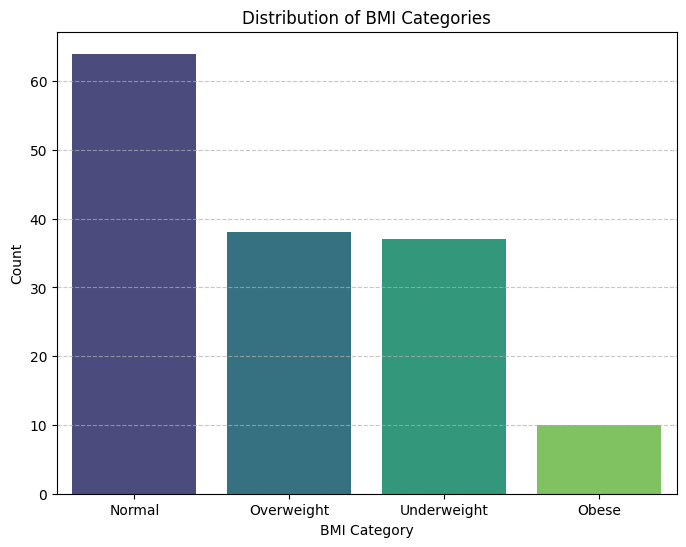

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(data=df_processed, x='BMI_CATEGORY', order=df_processed['BMI_CATEGORY'].value_counts().index, palette='viridis')
plt.title('Distribution of BMI Categories')
plt.xlabel('BMI Category')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

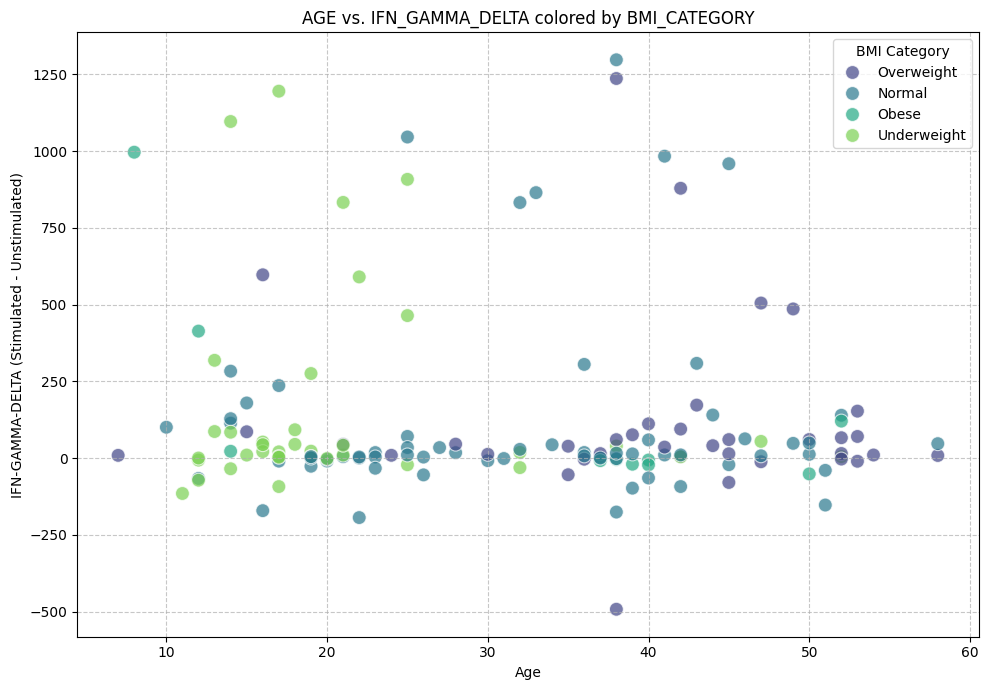

In [ ]:
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df_processed, x='AGE', y='IFN_GAMMA_DELTA', hue='BMI_CATEGORY', palette='viridis', s=100, alpha=0.7)
plt.title('AGE vs. IFN_GAMMA_DELTA colored by BMI_CATEGORY')
plt.xlabel('Age')
plt.ylabel('IFN-GAMMA-DELTA (Stimulated - Unstimulated)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='BMI Category')
plt.tight_layout()
plt.show()